# IPL Sentiment Pipeline Selector Lab  
## Beginner-friendly vectorizer × classifier experiment notebook

This notebook helps you **choose good vectorizers and classifiers** for the IPL sentiment challenge.

You will:

1. Load the IPL sentiment dataset from GitHub.
2. Understand the columns: `statement`, `subject_keyword`, and `sentiment`.
3. Add vectorizer recipes using beginner-friendly helper functions.
4. Add classifier recipes using beginner-friendly helper functions.
5. Automatically train all vectorizer × classifier combinations.
6. Compare pipelines using accuracy, Macro F1, speed, model size, and simplicity.
7. Shortlist models for the 300-row round.
8. Select your final **4 vectorizers + 4 classifiers**.
9. Generate a JSON submission that you can copy-paste into the Django webapp.

Dataset source used by default:

`https://raw.githubusercontent.com/HimanshuKhale/ipl_sentiment/main/ipl_sentiment_small_dataset.csv`

Important: Your goal is **not** to use the heaviest model. Your goal is to choose a useful, explainable, diverse, and efficient set of pipeline components.

# Submission philosophy

In this sprint, you are not only competing for accuracy.

A good submission should show:

- **Variety**: different vectorizer families and classifier families.
- **Reasoning**: why you chose each vectorizer and classifier.
- **Suitability**: simple models should be rewarded when they perform well.
- **Efficiency**: smaller/faster models are valuable.
- **Generalization**: models should work beyond one small dataset.

Bad strategy:

> Submit 4 versions of the same TF-IDF and 4 heavy classifiers.

Good strategy:

> Compare CountVectorizer, word TF-IDF, character TF-IDF, and HashingVectorizer with Naive Bayes, Logistic Regression, LinearSVC, and SGDClassifier.

In [1]:
# ============================================================
# STEP 0: Install/import libraries
# ============================================================

# Most environments already have these libraries.
# If something is missing, uncomment the next line and run it:
# !pip install pandas numpy scikit-learn matplotlib joblib

import json
import time
import os
import warnings
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ============================================================
# STEP 1: Load the 80-row dataset from GitHub
# ============================================================

DATA_URL_80R = "https://raw.githubusercontent.com/HimanshuKhale/ipl_sentiment/main/ipl_sentiment_small_dataset.csv"

# The notebook tries GitHub first.
# If GitHub is unavailable, place the CSV file in the same folder as this notebook
# and set LOCAL_DATA_PATH below.

LOCAL_DATA_PATH_80R = "ipl_sentiment_small_dataset.csv"

def load_dataset_from_github_or_local(url, local_path):
    try:
        df = pd.read_csv(url)
        print("Loaded dataset from GitHub:", url)
        return df
    except Exception as github_error:
        print("Could not load from GitHub. Trying local file...")
        print("GitHub error:", github_error)
        if Path(local_path).exists():
            df = pd.read_csv(local_path)
            print("Loaded local dataset:", local_path)
            return df
        raise FileNotFoundError(
            "Dataset could not be loaded from GitHub or local file. "
            "Please download the CSV and put it next to this notebook."
        )

df_80 = load_dataset_from_github_or_local(DATA_URL_80R, LOCAL_DATA_PATH_80R)

print("Shape:", df_80.shape)
display(df_80.head())
print("Columns:", list(df_80.columns))

Loaded dataset from GitHub: https://raw.githubusercontent.com/HimanshuKhale/ipl_sentiment/main/ipl_sentiment_small_dataset.csv
Shape: (80, 4)


,post_id,statement,subject_keyword,sentiment
0,1,"RCB finally played like champions today, the b...",RCB,positive
1,2,RCB fans deserve better than another middle or...,RCB,negative
2,3,RCB's batting was decent but the fielding stil...,RCB,neutral
3,4,Virat's energy makes RCB matches feel electric...,RCB,positive
4,5,"RCB again lost control in the death overs, sam...",RCB,negative


Columns: ['post_id', 'statement', 'subject_keyword', 'sentiment']


In [3]:
# ============================================================
# STEP 2: Clean and standardize the dataset
# ============================================================

# Required columns:
# statement = tweet/post text
# subject_keyword = IPL team or subject
# sentiment = positive/negative/neutral

required_columns = ["statement", "subject_keyword", "sentiment"]

missing = [col for col in required_columns if col not in df_80.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Your dataset must have {required_columns}")

df_80 = df_80.dropna(subset=required_columns).copy()
df_80["statement"] = df_80["statement"].astype(str)
df_80["subject_keyword"] = df_80["subject_keyword"].astype(str)
df_80["sentiment"] = df_80["sentiment"].astype(str).str.lower().str.strip()

# Entity-aware model text:
# This helps the model learn sentiment toward the keyword, not just general sentiment.
df_80["model_text"] = df_80["subject_keyword"] + " [SEP] " + df_80["statement"]

print("Cleaned shape:", df_80.shape)
print("\nSentiment distribution:")
display(df_80["sentiment"].value_counts())

print("\nTeam/keyword distribution:")
display(df_80["subject_keyword"].value_counts())

display(df_80[["model_text", "sentiment"]].head())

Cleaned shape: (80, 5)

Sentiment distribution:


,count
sentiment,
positive,28
negative,26
neutral,26



Team/keyword distribution:


,count
subject_keyword,
RCB,8
MI,8
CSK,8
KKR,8
SRH,8
RR,8
DC,8
PBKS,8
GT,8


,model_text,sentiment
0,RCB [SEP] RCB finally played like champions to...,positive
1,RCB [SEP] RCB fans deserve better than another...,negative
2,RCB [SEP] RCB's batting was decent but the fie...,neutral
3,RCB [SEP] Virat's energy makes RCB matches fee...,positive
4,RCB [SEP] RCB again lost control in the death ...,negative


In [4]:
# ============================================================
# STEP 3: Create train/test split for the 80R experiment
# ============================================================

X = df_80["model_text"]
y = df_80["sentiment"]

X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", len(X_train_80))
print("Testing rows:", len(X_test_80))
print("\nTrain label distribution:")
display(y_train_80.value_counts())
print("\nTest label distribution:")
display(y_test_80.value_counts())

Training rows: 60
Testing rows: 20

Train label distribution:


,count
sentiment,
positive,21
neutral,20
negative,19



Test label distribution:


,count
sentiment,
positive,7
negative,7
neutral,6


# STEP 4: Beginner-friendly recipe system

You do **not** need to write complex registration code.

You only need to call:

```python
add_vectorizer(...)
add_classifier(...)
```

Each vectorizer/classifier becomes a **recipe**.  
The notebook will later convert recipes into real sklearn objects.

A recipe has:

- `id`: short unique name
- `name`: readable name
- `family`: category, such as `count`, `tfidf_word`, `tfidf_char`, `hashing`
- `type`: sklearn class name
- `params`: settings
- `notes`: why you chose it
- `complexity`: `low`, `medium`, or `high`

In [5]:
# ============================================================
# STEP 4A: Helper functions for adding recipes
# ============================================================

vectorizer_recipes = []
classifier_recipes = []

def add_vectorizer(id, name, family, type, params=None, notes="", complexity="low"):
    """
    Add a vectorizer recipe.

    Example:
    add_vectorizer(
        id="tfidf_word_1_2",
        name="TF-IDF Word 1-2 grams",
        family="tfidf_word",
        type="TfidfVectorizer",
        params={"ngram_range": (1, 2), "max_features": 3000},
        notes="Good baseline for short text.",
        complexity="low"
    )
    """
    if params is None:
        params = {}
    vectorizer_recipes.append({
        "id": id,
        "name": name,
        "family": family,
        "type": type,
        "params": params,
        "notes": notes,
        "complexity": complexity,
    })

def add_classifier(id, name, family, type, params=None, notes="", complexity="low"):
    """
    Add a classifier recipe.

    Example:
    add_classifier(
        id="logreg_balanced",
        name="Logistic Regression Balanced",
        family="linear",
        type="LogisticRegression",
        params={"max_iter": 1000, "class_weight": "balanced"},
        notes="Strong simple classifier for sparse text.",
        complexity="low"
    )
    """
    if params is None:
        params = {}
    classifier_recipes.append({
        "id": id,
        "name": name,
        "family": family,
        "type": type,
        "params": params,
        "notes": notes,
        "complexity": complexity,
    })

print("Helper functions are ready.")

Helper functions are ready.


In [6]:
# ============================================================
# STEP 4B: Starter vectorizers
# ============================================================
# Beginners: You can keep these as they are.
# Advanced students: Add 1-2 more below, but do not submit near-duplicates.

add_vectorizer(
    id="count_basic",
    name="CountVectorizer Basic",
    family="count",
    type="CountVectorizer",
    params={
        "lowercase": True,
        "max_features": 3000
    },
    notes="Simple frequency baseline. Good for seeing whether word counts are enough.",
    complexity="low"
)

add_vectorizer(
    id="tfidf_word_1_2",
    name="TF-IDF Word 1-2 grams",
    family="tfidf_word",
    type="TfidfVectorizer",
    params={
        "lowercase": True,
        "ngram_range": (1, 2),
        "max_features": 4000
    },
    notes="Strong text baseline. Captures important words and short phrases.",
    complexity="low"
)

add_vectorizer(
    id="tfidf_char_3_5",
    name="TF-IDF Character 3-5 grams",
    family="tfidf_char",
    type="TfidfVectorizer",
    params={
        "analyzer": "char",
        "ngram_range": (3, 5),
        "max_features": 5000
    },
    notes="Useful for typos, Hinglish, team abbreviations, and social media spelling.",
    complexity="medium"
)

add_vectorizer(
    id="hashing_word",
    name="HashingVectorizer Word",
    family="hashing",
    type="HashingVectorizer",
    params={
        "alternate_sign": False,
        "n_features": 2048,
        "lowercase": True
    },
    notes="Scalable vectorizer. Does not store vocabulary, useful for bigger datasets.",
    complexity="medium"
)

# OPTIONAL: Add your own vectorizer below.
# Keep max_features small for localhost.
# Example:
# add_vectorizer(
#     id="tfidf_word_1_1",
#     name="TF-IDF Word Unigram",
#     family="tfidf_word",
#     type="TfidfVectorizer",
#     params={"lowercase": True, "ngram_range": (1, 1), "max_features": 3000},
#     notes="Tests whether single words are enough.",
#     complexity="low"
# )

print(f"Total vectorizers added: {len(vectorizer_recipes)}")
pd.DataFrame(vectorizer_recipes)

Total vectorizers added: 4


,id,name,family,type,params,notes,complexity
0,count_basic,CountVectorizer Basic,count,CountVectorizer,"{'lowercase': True, 'max_features': 3000}",Simple frequency baseline. Good for seeing whe...,low
1,tfidf_word_1_2,TF-IDF Word 1-2 grams,tfidf_word,TfidfVectorizer,"{'lowercase': True, 'ngram_range': (1, 2), 'ma...",Strong text baseline. Captures important words...,low
2,tfidf_char_3_5,TF-IDF Character 3-5 grams,tfidf_char,TfidfVectorizer,"{'analyzer': 'char', 'ngram_range': (3, 5), 'm...","Useful for typos, Hinglish, team abbreviations...",medium
3,hashing_word,HashingVectorizer Word,hashing,HashingVectorizer,"{'alternate_sign': False, 'n_features': 2048, ...",Scalable vectorizer. Does not store vocabulary...,medium


In [7]:
# ============================================================
# STEP 4C: Starter classifiers
# ============================================================
# Beginners: You can keep these as they are.
# Advanced students: Add 1-2 more below, but maximum one heavy classifier.

add_classifier(
    id="multinomial_nb",
    name="Multinomial Naive Bayes",
    family="probabilistic",
    type="MultinomialNB",
    params={},
    notes="Very fast and strong baseline for text classification.",
    complexity="low"
)

add_classifier(
    id="logreg_balanced",
    name="Logistic Regression Balanced",
    family="linear",
    type="LogisticRegression",
    params={
        "max_iter": 1000,
        "class_weight": "balanced",
        "random_state": RANDOM_STATE
    },
    notes="Simple, explainable, and often strong for TF-IDF features.",
    complexity="low"
)

add_classifier(
    id="linear_svc",
    name="LinearSVC",
    family="margin_based",
    type="LinearSVC",
    params={
        "random_state": RANDOM_STATE
    },
    notes="Strong classical classifier for high-dimensional text data.",
    complexity="medium"
)

add_classifier(
    id="sgd_log",
    name="SGDClassifier Logistic Loss",
    family="linear",
    type="SGDClassifier",
    params={
        "loss": "log_loss",
        "max_iter": 1000,
        "random_state": RANDOM_STATE
    },
    notes="Fast and scalable. Good for larger datasets.",
    complexity="medium"
)

# OPTIONAL heavy classifier. Use carefully.
# You may test it, but do not rely only on heavy models.
# add_classifier(
#     id="random_forest_small",
#     name="Small Random Forest",
#     family="tree_based",
#     type="RandomForestClassifier",
#     params={"n_estimators": 50, "max_depth": 10, "random_state": RANDOM_STATE},
#     notes="Tree-based model. Heavier and not always ideal for sparse text.",
#     complexity="high"
# )

print(f"Total classifiers added: {len(classifier_recipes)}")
pd.DataFrame(classifier_recipes)

Total classifiers added: 4


,id,name,family,type,params,notes,complexity
0,multinomial_nb,Multinomial Naive Bayes,probabilistic,MultinomialNB,{},Very fast and strong baseline for text classif...,low
1,logreg_balanced,Logistic Regression Balanced,linear,LogisticRegression,"{'max_iter': 1000, 'class_weight': 'balanced',...","Simple, explainable, and often strong for TF-I...",low
2,linear_svc,LinearSVC,margin_based,LinearSVC,{'random_state': 42},Strong classical classifier for high-dimension...,medium
3,sgd_log,SGDClassifier Logistic Loss,linear,SGDClassifier,"{'loss': 'log_loss', 'max_iter': 1000, 'random...",Fast and scalable. Good for larger datasets.,medium


In [8]:
# ============================================================
# STEP 5: Validate diversity rules
# ============================================================

def validate_recipe_diversity(vectorizers, classifiers):
    messages = []

    v_families = sorted(set(v["family"] for v in vectorizers))
    c_families = sorted(set(c["family"] for c in classifiers))
    heavy_classifiers = [c for c in classifiers if c.get("complexity") == "high"]

    messages.append(f"Vectorizer count: {len(vectorizers)}")
    messages.append(f"Classifier count: {len(classifiers)}")
    messages.append(f"Vectorizer families: {v_families}")
    messages.append(f"Classifier families: {c_families}")
    messages.append(f"Heavy classifiers: {[c['id'] for c in heavy_classifiers]}")

    warnings = []
    if len(vectorizers) < 4:
        warnings.append("Add at least 4 vectorizers before final submission.")
    if len(classifiers) < 4:
        warnings.append("Add at least 4 classifiers before final submission.")
    if len(v_families) < 3:
        warnings.append("Use at least 3 different vectorizer families.")
    if len(c_families) < 3:
        warnings.append("Use at least 3 different classifier families.")
    if len(heavy_classifiers) > 1:
        warnings.append("Use maximum 1 heavy classifier.")

    return messages, warnings

messages, warnings_list = validate_recipe_diversity(vectorizer_recipes, classifier_recipes)

print("\n".join(messages))
if warnings_list:
    print("\nWarnings:")
    for w in warnings_list:
        print("-", w)
else:
    print("\nDiversity check passed.")

Vectorizer count: 4
Classifier count: 4
Vectorizer families: ['count', 'hashing', 'tfidf_char', 'tfidf_word']
Classifier families: ['linear', 'margin_based', 'probabilistic']
Heavy classifiers: []

Diversity check passed.


In [9]:
# ============================================================
# STEP 6: Build actual sklearn objects from recipes
# ============================================================

VECTORIZER_CLASSES = {
    "CountVectorizer": CountVectorizer,
    "TfidfVectorizer": TfidfVectorizer,
    "HashingVectorizer": HashingVectorizer,
}

CLASSIFIER_CLASSES = {
    "MultinomialNB": MultinomialNB,
    "ComplementNB": ComplementNB,
    "LogisticRegression": LogisticRegression,
    "LinearSVC": LinearSVC,
    "SGDClassifier": SGDClassifier,
    "RandomForestClassifier": RandomForestClassifier,
}

def clean_params(params):
    # Convert lists to tuples for ngram_range if needed.
    params = deepcopy(params)
    if "ngram_range" in params and isinstance(params["ngram_range"], list):
        params["ngram_range"] = tuple(params["ngram_range"])
    return params

def build_vectorizer(recipe):
    cls = VECTORIZER_CLASSES[recipe["type"]]
    return cls(**clean_params(recipe.get("params", {})))

def build_classifier(recipe):
    cls = CLASSIFIER_CLASSES[recipe["type"]]
    return cls(**clean_params(recipe.get("params", {})))

def make_pipeline(vectorizer_recipe, classifier_recipe):
    return Pipeline([
        ("vectorizer", build_vectorizer(vectorizer_recipe)),
        ("classifier", build_classifier(classifier_recipe)),
    ])

print("Factory functions are ready.")

Factory functions are ready.


In [10]:
# ============================================================
# STEP 7: Train every vectorizer × classifier combination on 80R
# ============================================================

def estimate_model_size_kb(model, temp_path="temp_pipeline_model.joblib"):
    try:
        joblib.dump(model, temp_path)
        size_kb = os.path.getsize(temp_path) / 1024
        os.remove(temp_path)
        return size_kb
    except Exception:
        return np.nan

def complexity_penalty(v_recipe, c_recipe):
    # Higher complexity gets a small penalty in suitability score.
    levels = {"low": 0, "medium": 1, "high": 2}
    return levels.get(v_recipe.get("complexity", "low"), 0) + levels.get(c_recipe.get("complexity", "low"), 0)

def run_single_pipeline(v_recipe, c_recipe, X_train, X_test, y_train, y_test):
    result = {
        "vectorizer_id": v_recipe["id"],
        "vectorizer_name": v_recipe["name"],
        "vectorizer_family": v_recipe["family"],
        "vectorizer_complexity": v_recipe.get("complexity", "low"),
        "classifier_id": c_recipe["id"],
        "classifier_name": c_recipe["name"],
        "classifier_family": c_recipe["family"],
        "classifier_complexity": c_recipe.get("complexity", "low"),
        "pipeline_id": f"{v_recipe['id']}__{c_recipe['id']}",
    }

    try:
        pipeline = make_pipeline(v_recipe, c_recipe)

        start_train = time.time()
        pipeline.fit(X_train, y_train)
        train_time = time.time() - start_train

        start_pred = time.time()
        y_pred = pipeline.predict(X_test)
        pred_time = time.time() - start_pred

        acc = accuracy_score(y_test, y_pred)
        macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
        weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
        precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
        recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
        size_kb = estimate_model_size_kb(pipeline)

        # Simple scoring:
        # Performance is important, but efficient/simple models get rewarded too.
        performance_score = (macro_f1 * 60) + (acc * 25) + (weighted_f1 * 15)

        # Efficiency score rewards fast/small models.
        speed_score = max(0, 100 - (train_time * 10) - (pred_time * 100))
        size_score = max(0, 100 - (size_kb / 20)) if not np.isnan(size_kb) else 50
        efficiency_score = (speed_score * 0.6) + (size_score * 0.4)

        # Suitability rewards simpler models unless heavy models strongly outperform.
        penalty = complexity_penalty(v_recipe, c_recipe)
        suitability_score = max(0, 100 - penalty * 15)

        final_score = (
            performance_score * 0.55
            + efficiency_score * 0.20
            + suitability_score * 0.15
            + 100 * 0.10  # basic completion score
        )

        result.update({
            "status": "completed",
            "accuracy": acc,
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1,
            "precision_macro": precision_macro,
            "recall_macro": recall_macro,
            "train_time_sec": train_time,
            "prediction_time_sec": pred_time,
            "model_size_kb": size_kb,
            "performance_score": performance_score,
            "efficiency_score": efficiency_score,
            "suitability_score": suitability_score,
            "final_score": final_score,
            "error": "",
        })

    except Exception as e:
        result.update({
            "status": "failed",
            "accuracy": np.nan,
            "macro_f1": np.nan,
            "weighted_f1": np.nan,
            "precision_macro": np.nan,
            "recall_macro": np.nan,
            "train_time_sec": np.nan,
            "prediction_time_sec": np.nan,
            "model_size_kb": np.nan,
            "performance_score": 0,
            "efficiency_score": 0,
            "suitability_score": 0,
            "final_score": 0,
            "error": str(e),
        })

    return result

all_results = []
total_runs = len(vectorizer_recipes) * len(classifier_recipes)
print(f"Running {total_runs} pipelines...")

for v in vectorizer_recipes:
    for c in classifier_recipes:
        print(f"Training: {v['id']} + {c['id']}")
        result = run_single_pipeline(v, c, X_train_80, X_test_80, y_train_80, y_test_80)
        all_results.append(result)

results_80 = pd.DataFrame(all_results).sort_values("final_score", ascending=False).reset_index(drop=True)
results_80.insert(0, "rank", range(1, len(results_80) + 1))

print("Done.")
display(results_80)

Running 16 pipelines...
Training: count_basic + multinomial_nb
Training: count_basic + logreg_balanced
Training: count_basic + linear_svc
Training: count_basic + sgd_log
Training: tfidf_word_1_2 + multinomial_nb
Training: tfidf_word_1_2 + logreg_balanced
Training: tfidf_word_1_2 + linear_svc
Training: tfidf_word_1_2 + sgd_log
Training: tfidf_char_3_5 + multinomial_nb
Training: tfidf_char_3_5 + logreg_balanced
Training: tfidf_char_3_5 + linear_svc
Training: tfidf_char_3_5 + sgd_log
Training: hashing_word + multinomial_nb
Training: hashing_word + logreg_balanced
Training: hashing_word + linear_svc
Training: hashing_word + sgd_log
Done.


,rank,vectorizer_id,vectorizer_name,vectorizer_family,vectorizer_complexity,classifier_id,classifier_name,classifier_family,classifier_complexity,pipeline_id,...,precision_macro,recall_macro,train_time_sec,prediction_time_sec,model_size_kb,performance_score,efficiency_score,suitability_score,final_score,error
0,1,count_basic,CountVectorizer Basic,count,low,logreg_balanced,Logistic Regression Balanced,linear,low,count_basic__logreg_balanced,...,0.666667,0.666667,0.024765,0.001095,16.687500,64.784759,99.451988,100,80.522015,
1,2,hashing_word,HashingVectorizer Word,hashing,medium,multinomial_nb,Multinomial Naive Bayes,probabilistic,low,hashing_word__multinomial_nb,...,0.666667,0.666667,0.002935,0.000725,97.336914,62.308480,97.992147,85,76.618093,
2,3,count_basic,CountVectorizer Basic,count,low,multinomial_nb,Multinomial Naive Bayes,probabilistic,low,count_basic__multinomial_nb,...,0.563492,0.619048,0.029501,0.002805,23.458008,57.518326,99.185563,100,76.472192,
3,4,count_basic,CountVectorizer Basic,count,low,linear_svc,LinearSVC,margin_based,medium,count_basic__linear_svc,...,0.651515,0.611111,0.004430,0.000769,16.511719,60.482323,99.597023,85,75.934682,
4,5,hashing_word,HashingVectorizer Word,hashing,medium,logreg_balanced,Logistic Regression Balanced,linear,low,hashing_word__logreg_balanced,...,0.614815,0.619048,0.009250,0.001088,49.500977,60.541667,98.889208,85,75.825758,
5,6,count_basic,CountVectorizer Basic,count,low,sgd_log,SGDClassifier Logistic Loss,linear,medium,count_basic__sgd_log,...,0.583333,0.619048,0.005753,0.000845,16.828125,56.464052,99.578209,85,73.720871,
6,7,hashing_word,HashingVectorizer Word,hashing,medium,linear_svc,LinearSVC,margin_based,medium,hashing_word__linear_svc,...,0.595960,0.619048,0.005394,0.000984,49.356445,58.577778,98.921484,70,72.502075,
7,8,hashing_word,HashingVectorizer Word,hashing,medium,sgd_log,SGDClassifier Logistic Loss,linear,medium,hashing_word__sgd_log,...,0.517196,0.571429,0.004620,0.001026,49.625977,53.581294,98.918221,70,69.753356,
8,9,tfidf_char_3_5,TF-IDF Character 3-5 grams,tfidf_char,medium,logreg_balanced,Logistic Regression Balanced,linear,low,tfidf_char_3_5__logreg_balanced,...,0.462963,0.507937,0.134969,0.008744,285.910156,47.331250,92.947346,85,67.371657,
9,10,tfidf_char_3_5,TF-IDF Character 3-5 grams,tfidf_char,medium,linear_svc,LinearSVC,margin_based,medium,tfidf_char_3_5__linear_svc,...,0.482540,0.507937,0.022130,0.004217,285.765625,47.835714,93.898910,70,65.589425,


In [11]:
# ============================================================
# STEP 8: Save and inspect 80R results
# ============================================================

results_80.to_csv("results_80R.csv", index=False)
print("Saved: results_80R.csv")

print("\nTop 10 pipelines by final_score:")
display(results_80.head(10)[[
    "rank",
    "pipeline_id",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "train_time_sec",
    "model_size_kb",
    "final_score",
    "status",
]])

print("\nFailed pipelines, if any:")
display(results_80[results_80["status"] == "failed"][["pipeline_id", "error"]])

Saved: results_80R.csv

Top 10 pipelines by final_score:


,rank,pipeline_id,accuracy,macro_f1,weighted_f1,train_time_sec,model_size_kb,final_score,status
0,1,count_basic__logreg_balanced,0.65,0.650624,0.633155,0.024765,16.687500,80.522015,completed
1,2,hashing_word__multinomial_nb,0.65,0.617934,0.598830,0.002935,97.336914,76.618093,completed
2,3,count_basic__multinomial_nb,0.60,0.570437,0.552805,0.029501,23.458008,76.472192,completed
3,4,count_basic__linear_svc,0.60,0.609428,0.594444,0.004430,16.511719,75.934682,completed
4,5,hashing_word__logreg_balanced,0.60,0.611111,0.591667,0.009250,49.500977,75.825758,completed
5,6,count_basic__sgd_log,0.60,0.555867,0.540803,0.005753,16.828125,73.720871,completed
6,7,hashing_word__linear_svc,0.60,0.585185,0.564444,0.005394,49.356445,72.502075,completed
7,8,hashing_word__sgd_log,0.55,0.534965,0.515559,0.004620,49.625977,69.753356,completed
8,9,tfidf_char_3_5__logreg_balanced,0.50,0.465476,0.460179,0.134969,285.910156,67.371657,completed
9,10,tfidf_char_3_5__linear_svc,0.50,0.471429,0.470000,0.022130,285.765625,65.589425,completed



Failed pipelines, if any:


,pipeline_id,error


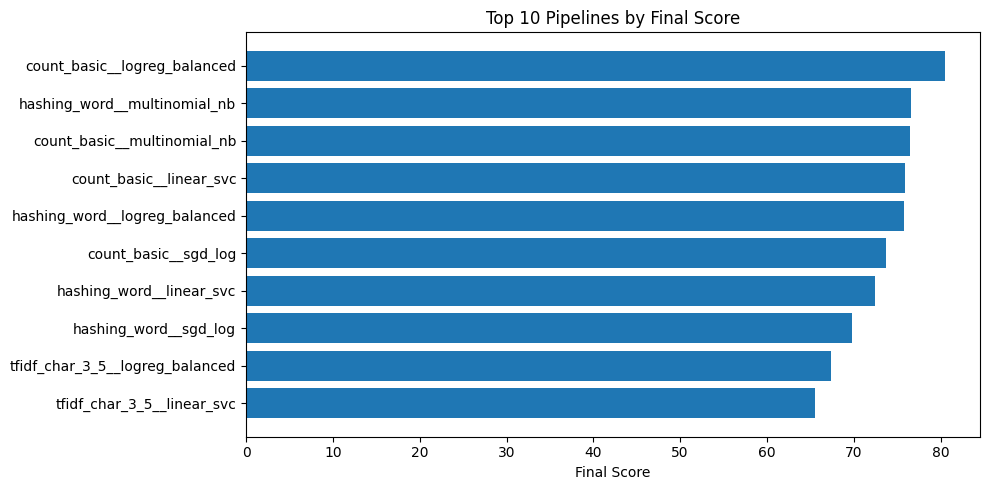

Average performance by vectorizer family:


,macro_f1,accuracy,final_score
vectorizer_family,,,
count,0.596589,0.6125,76.662440
hashing,0.587299,0.6000,73.674820
tfidf_char,0.434408,0.4625,64.502835
tfidf_word,0.321210,0.3250,61.341666


Average performance by classifier family:


,macro_f1,accuracy,final_score
classifier_family,,,
probabilistic,0.469943,0.50000,69.430201
margin_based,0.506769,0.51250,69.055432
linear,0.481397,0.49375,68.848064


In [12]:
# ============================================================
# STEP 9: Visual analytics
# ============================================================

completed = results_80[results_80["status"] == "completed"].copy()

if completed.empty:
    print("No completed models to visualize.")
else:
    top_plot = completed.sort_values("final_score", ascending=False).head(10)

    plt.figure(figsize=(10, 5))
    plt.barh(top_plot["pipeline_id"][::-1], top_plot["final_score"][::-1])
    plt.xlabel("Final Score")
    plt.title("Top 10 Pipelines by Final Score")
    plt.tight_layout()
    plt.show()

    family_perf = completed.groupby("vectorizer_family")[["macro_f1", "accuracy", "final_score"]].mean().sort_values("final_score", ascending=False)
    print("Average performance by vectorizer family:")
    display(family_perf)

    clf_perf = completed.groupby("classifier_family")[["macro_f1", "accuracy", "final_score"]].mean().sort_values("final_score", ascending=False)
    print("Average performance by classifier family:")
    display(clf_perf)

# STEP 10: Understand one selected pipeline

Use this section to inspect the confusion matrix and classification report of a pipeline.

By default, it chooses the top-ranked pipeline.  
You can change `SELECTED_PIPELINE_ID` to any pipeline from `results_80`.

In [13]:
# ============================================================
# STEP 10A: Detailed report for one pipeline
# ============================================================

SELECTED_PIPELINE_ID = results_80.iloc[0]["pipeline_id"]  # change this if needed

selected_row = results_80[results_80["pipeline_id"] == SELECTED_PIPELINE_ID].iloc[0]
v_recipe = next(v for v in vectorizer_recipes if v["id"] == selected_row["vectorizer_id"])
c_recipe = next(c for c in classifier_recipes if c["id"] == selected_row["classifier_id"])

pipeline = make_pipeline(v_recipe, c_recipe)
pipeline.fit(X_train_80, y_train_80)
y_pred = pipeline.predict(X_test_80)

print("Selected pipeline:", SELECTED_PIPELINE_ID)
print("\nClassification report:")
print(classification_report(y_test_80, y_pred, zero_division=0))

labels = sorted(y.unique())
cm = confusion_matrix(y_test_80, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"actual_{l}" for l in labels], columns=[f"pred_{l}" for l in labels])
display(cm_df)

Selected pipeline: count_basic__logreg_balanced

Classification report:
              precision    recall  f1-score   support

    negative       0.50      0.29      0.36         7
     neutral       1.00      1.00      1.00         6
    positive       0.50      0.71      0.59         7

    accuracy                           0.65        20
   macro avg       0.67      0.67      0.65        20
weighted avg       0.65      0.65      0.63        20



,pred_negative,pred_neutral,pred_positive
actual_negative,2,0,5
actual_neutral,0,6,0
actual_positive,2,0,5


# STEP 11: Shortlist candidates for the 300R round

The notebook will suggest candidates using two ideas:

1. Top pipelines by score.
2. Best representative from each vectorizer/classifier family.

This helps avoid the mistake of selecting only one type of model.

In [14]:
# ============================================================
# STEP 11A: Candidate shortlist
# ============================================================

def make_candidate_shortlist(results_df, top_n=8):
    completed = results_df[results_df["status"] == "completed"].copy()
    if completed.empty:
        return completed

    top_overall = completed.sort_values("final_score", ascending=False).head(top_n)

    best_by_vectorizer_family = (
        completed.sort_values("final_score", ascending=False)
        .groupby("vectorizer_family")
        .head(1)
    )

    best_by_classifier_family = (
        completed.sort_values("final_score", ascending=False)
        .groupby("classifier_family")
        .head(1)
    )

    shortlist = pd.concat([top_overall, best_by_vectorizer_family, best_by_classifier_family])
    shortlist = shortlist.drop_duplicates(subset=["pipeline_id"])
    shortlist = shortlist.sort_values("final_score", ascending=False).reset_index(drop=True)
    shortlist.insert(0, "candidate_rank", range(1, len(shortlist) + 1))
    return shortlist

candidate_shortlist = make_candidate_shortlist(results_80, top_n=8)

print("Candidate shortlist for 300R round:")
display(candidate_shortlist[[
    "candidate_rank",
    "pipeline_id",
    "vectorizer_family",
    "classifier_family",
    "accuracy",
    "macro_f1",
    "final_score"
]])

Candidate shortlist for 300R round:


,candidate_rank,pipeline_id,vectorizer_family,classifier_family,accuracy,macro_f1,final_score
0,1,count_basic__logreg_balanced,count,linear,0.65,0.650624,80.522015
1,2,hashing_word__multinomial_nb,hashing,probabilistic,0.65,0.617934,76.618093
2,3,count_basic__multinomial_nb,count,probabilistic,0.60,0.570437,76.472192
3,4,count_basic__linear_svc,count,margin_based,0.60,0.609428,75.934682
4,5,hashing_word__logreg_balanced,hashing,linear,0.60,0.611111,75.825758
5,6,count_basic__sgd_log,count,linear,0.60,0.555867,73.720871
6,7,hashing_word__linear_svc,hashing,margin_based,0.60,0.585185,72.502075
7,8,hashing_word__sgd_log,hashing,linear,0.55,0.534965,69.753356
8,9,tfidf_char_3_5__logreg_balanced,tfidf_char,linear,0.50,0.465476,67.371657
9,10,tfidf_word_1_2__linear_svc,tfidf_word,margin_based,0.35,0.361033,62.195546


# STEP 12: Optional 300R round

Use this only after you have a 300-row dataset.

The notebook tries these options:

1. If you upload or place `ipl_300R_indian_english_sentiment_dataset.csv` next to the notebook, it will load it.
2. If you put the 300R dataset in GitHub later, paste the raw GitHub URL into `DATA_URL_300R`.
3. If you do not have 300R yet, skip this section.

Expected 300R columns can be either:

- `tweet`, `subject_keyword`, `sentiment`
- or `statement`, `subject_keyword`, `sentiment`

If the column is `tweet`, the notebook renames it to `statement`.

In [15]:
# ============================================================
# STEP 12A: Load optional 300R dataset
# ============================================================

# Paste a raw GitHub URL here if you add the 300R CSV to the repo.
# Example:
# DATA_URL_300R = "https://raw.githubusercontent.com/HimanshuKhale/ipl_sentiment/main/ipl_300R_indian_english_sentiment_dataset.csv"

DATA_URL_300R = ""
LOCAL_DATA_PATH_300R = "ipl_300R_indian_english_sentiment_dataset.csv"

def load_optional_300R():
    if DATA_URL_300R:
        try:
            df = pd.read_csv(DATA_URL_300R)
            print("Loaded 300R from GitHub:", DATA_URL_300R)
            return df
        except Exception as e:
            print("Could not load DATA_URL_300R:", e)

    if Path(LOCAL_DATA_PATH_300R).exists():
        df = pd.read_csv(LOCAL_DATA_PATH_300R)
        print("Loaded local 300R dataset:", LOCAL_DATA_PATH_300R)
        return df

    print("No 300R dataset found. You can skip the 300R section for now.")
    return None

df_300 = load_optional_300R()

if df_300 is not None:
    if "tweet" in df_300.columns and "statement" not in df_300.columns:
        df_300 = df_300.rename(columns={"tweet": "statement"})

    missing = [col for col in required_columns if col not in df_300.columns]
    if missing:
        raise ValueError(f"300R dataset is missing required columns: {missing}")

    df_300 = df_300.dropna(subset=required_columns).copy()
    df_300["statement"] = df_300["statement"].astype(str)
    df_300["subject_keyword"] = df_300["subject_keyword"].astype(str)
    df_300["sentiment"] = df_300["sentiment"].astype(str).str.lower().str.strip()
    df_300["model_text"] = df_300["subject_keyword"] + " [SEP] " + df_300["statement"]

    print("300R shape:", df_300.shape)
    display(df_300.head())
    display(df_300["sentiment"].value_counts())

No 300R dataset found. You can skip the 300R section for now.


In [16]:
# ============================================================
# STEP 12B: Run shortlisted pipelines on 300R
# ============================================================

if df_300 is None:
    print("Skipping 300R experiment because no 300R dataset was loaded.")
    results_300 = pd.DataFrame()
else:
    X_300 = df_300["model_text"]
    y_300 = df_300["sentiment"]

    X_train_300, X_test_300, y_train_300, y_test_300 = train_test_split(
        X_300,
        y_300,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=y_300
    )

    selected_pipeline_ids_for_300R = candidate_shortlist["pipeline_id"].tolist()

    results_300_list = []
    print(f"Running {len(selected_pipeline_ids_for_300R)} shortlisted pipelines on 300R...")

    for pid in selected_pipeline_ids_for_300R:
        row = results_80[results_80["pipeline_id"] == pid].iloc[0]
        v_recipe = next(v for v in vectorizer_recipes if v["id"] == row["vectorizer_id"])
        c_recipe = next(c for c in classifier_recipes if c["id"] == row["classifier_id"])
        print(f"300R training: {pid}")
        result = run_single_pipeline(v_recipe, c_recipe, X_train_300, X_test_300, y_train_300, y_test_300)
        results_300_list.append(result)

    results_300 = pd.DataFrame(results_300_list).sort_values("final_score", ascending=False).reset_index(drop=True)
    results_300.insert(0, "rank_300R", range(1, len(results_300) + 1))
    results_300.to_csv("results_300R.csv", index=False)

    print("Saved: results_300R.csv")
    display(results_300)

Skipping 300R experiment because no 300R dataset was loaded.


# STEP 13: Select final 4 vectorizers and 4 classifiers

This is the most important submission step.

Rules:

- Select exactly **4 vectorizers**.
- Select exactly **4 classifiers**.
- Vectorizers should come from at least **3 different families**.
- Classifiers should come from at least **3 different families**.
- Maximum **1 heavy classifier**.
- Do not select duplicates or near-duplicates.
- Include at least one simple baseline.

Edit the lists below after reviewing your 80R and 300R results.

In [17]:
# ============================================================
# STEP 13A: Final selection
# ============================================================
# Edit only the IDs in these two lists.
# Use the tables below to check available IDs.

print("Available vectorizers:")
display(pd.DataFrame(vectorizer_recipes)[["id", "name", "family", "complexity", "notes"]])

print("Available classifiers:")
display(pd.DataFrame(classifier_recipes)[["id", "name", "family", "complexity", "notes"]])

# Default good beginner selection:
FINAL_VECTORIZER_IDS = [
    "count_basic",
    "tfidf_word_1_2",
    "tfidf_char_3_5",
    "hashing_word",
]

FINAL_CLASSIFIER_IDS = [
    "multinomial_nb",
    "logreg_balanced",
    "linear_svc",
    "sgd_log",
]

final_vectorizers = [v for v in vectorizer_recipes if v["id"] in FINAL_VECTORIZER_IDS]
final_classifiers = [c for c in classifier_recipes if c["id"] in FINAL_CLASSIFIER_IDS]

print("Selected vectorizers:", [v["id"] for v in final_vectorizers])
print("Selected classifiers:", [c["id"] for c in final_classifiers])

messages, warnings_list = validate_recipe_diversity(final_vectorizers, final_classifiers)
print("\n".join(messages))
if warnings_list:
    print("\nWarnings:")
    for w in warnings_list:
        print("-", w)
else:
    print("\nFinal diversity check passed.")

Available vectorizers:


,id,name,family,complexity,notes
0,count_basic,CountVectorizer Basic,count,low,Simple frequency baseline. Good for seeing whe...
1,tfidf_word_1_2,TF-IDF Word 1-2 grams,tfidf_word,low,Strong text baseline. Captures important words...
2,tfidf_char_3_5,TF-IDF Character 3-5 grams,tfidf_char,medium,"Useful for typos, Hinglish, team abbreviations..."
3,hashing_word,HashingVectorizer Word,hashing,medium,Scalable vectorizer. Does not store vocabulary...


Available classifiers:


,id,name,family,complexity,notes
0,multinomial_nb,Multinomial Naive Bayes,probabilistic,low,Very fast and strong baseline for text classif...
1,logreg_balanced,Logistic Regression Balanced,linear,low,"Simple, explainable, and often strong for TF-I..."
2,linear_svc,LinearSVC,margin_based,medium,Strong classical classifier for high-dimension...
3,sgd_log,SGDClassifier Logistic Loss,linear,medium,Fast and scalable. Good for larger datasets.


Selected vectorizers: ['count_basic', 'tfidf_word_1_2', 'tfidf_char_3_5', 'hashing_word']
Selected classifiers: ['multinomial_nb', 'logreg_balanced', 'linear_svc', 'sgd_log']
Vectorizer count: 4
Classifier count: 4
Vectorizer families: ['count', 'hashing', 'tfidf_char', 'tfidf_word']
Classifier families: ['linear', 'margin_based', 'probabilistic']
Heavy classifiers: []

Final diversity check passed.


In [25]:
# ============================================================
# STEP 14: Generate JSON submission manifest
# ============================================================

def json_safe(obj):
    # Convert tuples and numpy values to JSON-safe types.
    if isinstance(obj, tuple):
        return list(obj)
    if isinstance(obj, dict):
        return {k: json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [json_safe(x) for x in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    return obj

STUDENT_NAME = "SANVI A REDDY"
TEAM_NAME = "GROUP 3"

# Explain your research thinking in 3-5 lines.
STUDENT_HYPOTHESIS = (
    "I selected Count, TF-IDF word, TF-IDF character, and Hashing vectorizers to capture frequency patterns, phrase importance, spelling variations, team abbreviations, and scalability."
    "These approaches are suitable for noisy IPL social media text containing typos, Hinglish, and informal expressions. I selected probabilistic, linear, margin-based, and SGD classifiers to balance interpretability, speed, efficiency, and generalization across sparse text features."
)

best_80_pipeline = results_80.iloc[0].to_dict()

if "results_300" in globals() and isinstance(results_300, pd.DataFrame) and not results_300.empty:
    best_300_pipeline = results_300.iloc[0].to_dict()
else:
    best_300_pipeline = None

submission_manifest = {
    "student_name": STUDENT_NAME,
    "team_name": TEAM_NAME,
    "task_type": "entity_aware_sentiment_classification",
    "dataset_used_for_initial_experiment": "ipl_sentiment_small_dataset.csv",
    "target_labels": sorted(df_80["sentiment"].unique().tolist()),
    "model_input_format": "subject_keyword + ' [SEP] ' + statement",
    "hypothesis": STUDENT_HYPOTHESIS,
    "final_vectorizers": json_safe(final_vectorizers),
    "final_classifiers": json_safe(final_classifiers),
    "best_80R_pipeline": json_safe(best_80_pipeline),
    "best_300R_pipeline": json_safe(best_300_pipeline),
    "files_expected": [
        "completed_notebook.ipynb",
        "submission_manifest.json",
        "results_80R.csv",
        "results_300R.csv if 300R was used"
    ],
}

print(json.dumps(submission_manifest, indent=2))

with open("submission_manifest.json", "w", encoding="utf-8") as f:
    json.dump(submission_manifest, f, indent=2)

print("\nSaved: submission_manifest.json")

{
  "student_name": "SANVI A REDDY",
  "team_name": "GROUP 3",
  "task_type": "entity_aware_sentiment_classification",
  "dataset_used_for_initial_experiment": "ipl_sentiment_small_dataset.csv",
  "target_labels": [
    "negative",
    "neutral",
    "positive"
  ],
  "model_input_format": "subject_keyword + ' [SEP] ' + statement",
  "hypothesis": "I selected Count, TF-IDF word, TF-IDF character, and Hashing vectorizers to capture frequency patterns, phrase importance, spelling variations, team abbreviations, and scalability.These approaches are suitable for noisy IPL social media text containing typos, Hinglish, and informal expressions. I selected probabilistic, linear, margin-based, and SGD classifiers to balance interpretability, speed, efficiency, and generalization across sparse text features.",
  "final_vectorizers": [
    {
      "id": "count_basic",
      "name": "CountVectorizer Basic",
      "family": "count",
      "type": "CountVectorizer",
      "params": {
        "lower

# STEP 15: Final checklist before submission

Submit these files:

1. Your completed notebook: `.ipynb`
2. `submission_manifest.json`
3. `results_80R.csv`
4. `results_300R.csv` if you used the 300-row dataset

Your final JSON must contain exactly:

- 4 vectorizers
- 4 classifiers

Before submitting, check:

- Did you write your name and team name?
- Did your notebook run from top to bottom?
- Did you avoid near-duplicate choices?
- Did you include at least 3 vectorizer families?
- Did you include at least 3 classifier families?
- Did you explain why you chose the final 4+4?
- Did you avoid using many heavy models?
- Did your model input include the subject keyword?

Remember: a simple, explainable, fast model with decent performance can score better than a heavy model with only slightly higher accuracy.

In [19]:
# ============================================================
# OPTIONAL: Save your best 80R pipeline as a demo pkl
# ============================================================
# This is only for your own practice. The official Django app may retrain models itself.

SAVE_DEMO_BEST_PIPELINE = False

if SAVE_DEMO_BEST_PIPELINE:
    best_row = results_80.iloc[0]
    v_recipe = next(v for v in vectorizer_recipes if v["id"] == best_row["vectorizer_id"])
    c_recipe = next(c for c in classifier_recipes if c["id"] == best_row["classifier_id"])

    best_pipeline = make_pipeline(v_recipe, c_recipe)
    best_pipeline.fit(X, y)  # Train on all 80 rows only for demo use.

    joblib.dump(best_pipeline, "demo_best_80R_pipeline.pkl")
    print("Saved: demo_best_80R_pipeline.pkl")

    sample_text = "RCB [SEP] rcb batting mast thi but bowling thoda weak lag rhi hai"
    print("Sample prediction:", best_pipeline.predict([sample_text])[0])
else:
    print("Demo pickle saving is off. Set SAVE_DEMO_BEST_PIPELINE = True if needed.")

Demo pickle saving is off. Set SAVE_DEMO_BEST_PIPELINE = True if needed.


In [20]:
results_80.head()

,rank,vectorizer_id,vectorizer_name,vectorizer_family,vectorizer_complexity,classifier_id,classifier_name,classifier_family,classifier_complexity,pipeline_id,...,precision_macro,recall_macro,train_time_sec,prediction_time_sec,model_size_kb,performance_score,efficiency_score,suitability_score,final_score,error
0,1,count_basic,CountVectorizer Basic,count,low,logreg_balanced,Logistic Regression Balanced,linear,low,count_basic__logreg_balanced,...,0.666667,0.666667,0.024765,0.001095,16.687500,64.784759,99.451988,100,80.522015,
1,2,hashing_word,HashingVectorizer Word,hashing,medium,multinomial_nb,Multinomial Naive Bayes,probabilistic,low,hashing_word__multinomial_nb,...,0.666667,0.666667,0.002935,0.000725,97.336914,62.308480,97.992147,85,76.618093,
2,3,count_basic,CountVectorizer Basic,count,low,multinomial_nb,Multinomial Naive Bayes,probabilistic,low,count_basic__multinomial_nb,...,0.563492,0.619048,0.029501,0.002805,23.458008,57.518326,99.185563,100,76.472192,
3,4,count_basic,CountVectorizer Basic,count,low,linear_svc,LinearSVC,margin_based,medium,count_basic__linear_svc,...,0.651515,0.611111,0.004430,0.000769,16.511719,60.482323,99.597023,85,75.934682,
4,5,hashing_word,HashingVectorizer Word,hashing,medium,logreg_balanced,Logistic Regression Balanced,linear,low,hashing_word__logreg_balanced,...,0.614815,0.619048,0.009250,0.001088,49.500977,60.541667,98.889208,85,75.825758,


In [21]:
print(results_80.columns)

Index(['rank', 'vectorizer_id', 'vectorizer_name', 'vectorizer_family',
       'vectorizer_complexity', 'classifier_id', 'classifier_name',
       'classifier_family', 'classifier_complexity', 'pipeline_id', 'status',
       'accuracy', 'macro_f1', 'weighted_f1', 'precision_macro',
       'recall_macro', 'train_time_sec', 'prediction_time_sec',
       'model_size_kb', 'performance_score', 'efficiency_score',
       'suitability_score', 'final_score', 'error'],
      dtype='object')


In [22]:
results_80["status"].value_counts()

,count
status,
completed,16


In [23]:
results_80.to_csv("results_80R.csv", index=False)

In [26]:
import os

required_files = [
    "submission_manifest.json",
    "results_80R.csv"
]

for file in required_files:
    print(file, "✓" if os.path.exists(file) else "✗")

submission_manifest.json ✓
results_80R.csv ✓
